# 1. Initialization and Environment Setup

In [17]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

# 2. Data Loading, Cleaning, and Aggregation

In [18]:
# Loading
wolf_df = pd.read_csv('DenaliWolfPopulation.csv')
bird_df = pd.read_csv('sample_occurrence.csv', low_memory=False)

# Handling missing values (1 report without explicit count = at least 1 individual)
bird_df['individualCount'] = bird_df['individualCount'].fillna(1)

# Calculating the number of sightings (observation rows) per year
sightings_per_year = bird_df.groupby('year').size().reset_index(name='Nombre_Signalements')

# Calculating the total cumulative individuals per year
individuals_per_year = bird_df.groupby('year')['individualCount'].sum().reset_index(name='Total_Individus')

# Merging ornithological metrics
bird_summary = pd.merge(sightings_per_year, individuals_per_year, on='year')

# Calculating the ratio: total cumulative individuals / number of sightings
bird_summary['Bird_Ratio'] = bird_summary['Total_Individus'] / bird_summary['Nombre_Signalements']

# Merging with wolf data
df = pd.merge(wolf_df, bird_summary, left_on='Year', right_on='year', how='inner')

# Extracting variables (Raw variables, without standardization)
wolves_x = df['Wolves_Counted_Fall'].values
birds_ratio_y = df['Bird_Ratio'].values

# Data verification
df[['Year', 'Wolves_Counted_Fall', 'Total_Individus', 'Nombre_Signalements', 'Bird_Ratio']].head()

,Year,Wolves_Counted_Fall,Total_Individus,Nombre_Signalements,Bird_Ratio
0,1986,22,7.0,7,1.000000
1,1988,121,15.0,10,1.500000
2,1989,127,16.0,6,2.666667
3,1990,136,75.0,36,2.083333
4,1991,137,14.0,10,1.400000


# 3. Visual Exploratory Analysis: Time Series

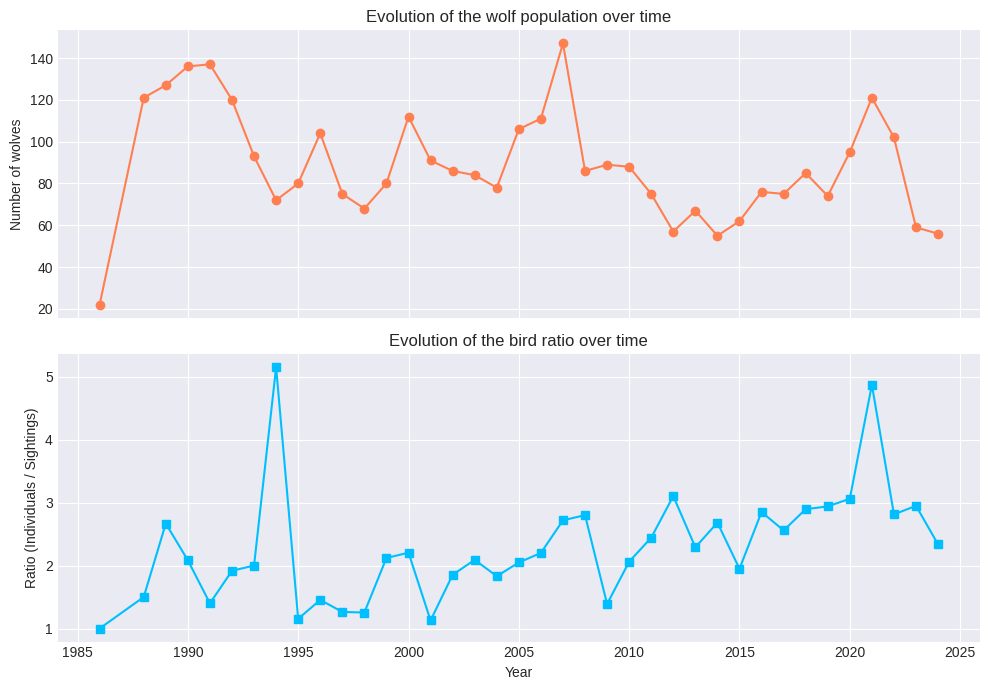

In [19]:
# 2. Separate but temporally aligned charts
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top chart: Wolves
ax1.plot(df['Year'], df['Wolves_Counted_Fall'], color='coral', marker='o', label='Wolves')
ax1.set_ylabel('Number of wolves')
ax1.set_title('Evolution of the wolf population over time')
ax1.grid(True)

# Bottom chart: Birds
ax2.plot(df['Year'], df['Bird_Ratio'], color='deepskyblue', marker='s', label='Bird Ratio')
ax2.set_xlabel('Year')
ax2.set_ylabel('Ratio (Individuals / Sightings)')
ax2.set_title('Evolution of the bird ratio over time')
ax2.grid(True)

plt.tight_layout()
plt.show()

# 4. Direct Relationship Analysis (Scatter Plot)

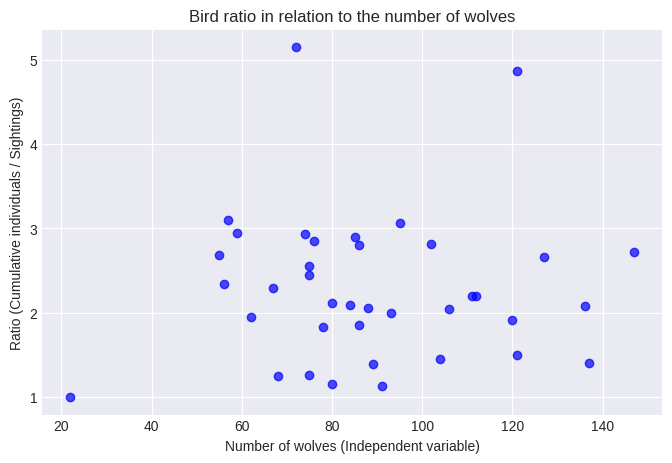

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(wolves_x, birds_ratio_y, color='blue', alpha=0.7)
plt.title("Bird ratio in relation to the number of wolves")
plt.xlabel("Number of wolves (Independent variable)")
plt.ylabel("Ratio (Cumulative individuals / Sightings)")
plt.show()

# 5. Bayesian Linear Model Specification and Sampling

We define a linear regression model where:


$$\mu = \alpha + \beta \times \text{wolves}_x$$

$$y_{obs} \sim \mathcal{N}(\mu, \sigma)$$

Since the raw data are not standardized, the prior distributions (priors) chosen for the y-intercept ($\alpha$) and the slope ($\beta$) are intentionally wide (weakly informative) to let the data guide the posterior distribution. Sampling is performed using the MCMC NUTS algorithm.

In [21]:
with pm.Model() as linear_model:
    # Large priors adapted to non-standardized data
    alpha = pm.Normal('alpha', mu=0, sigma=100) # Intercept
    beta = pm.Normal('beta', mu=0, sigma=10)    # Slope
    sigma = pm.HalfNormal('sigma', sigma=10)    # Noise
    
    # Linear model (Mean)
    mu = alpha + beta * wolves_x
    
    # Likelihood - Normal distribution because the ratio is a continuous variable
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=birds_ratio_y)
    
    # Sampling (MCMC)
    trace = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.9, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


/var/data/python/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 7 seconds.


# 6. Convergence Diagnostics and Parameter Summary

To validate the reliability of the estimates, we display the statistical summary of the posterior distribution parameters (HDI intervals, $\hat{R}$ metrics) as well as the MCMC trace plots to visually check for proper chain mixing.

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,2.181,0.522,1.341,3.017,2270.913,3108.299,1.001,0.011,0.008
beta,0.001,0.006,-0.008,0.010,2182.137,3017.125,1.001,0.000,0.000
sigma,0.930,0.113,0.768,1.124,3646.661,3763.426,1.002,0.002,0.002


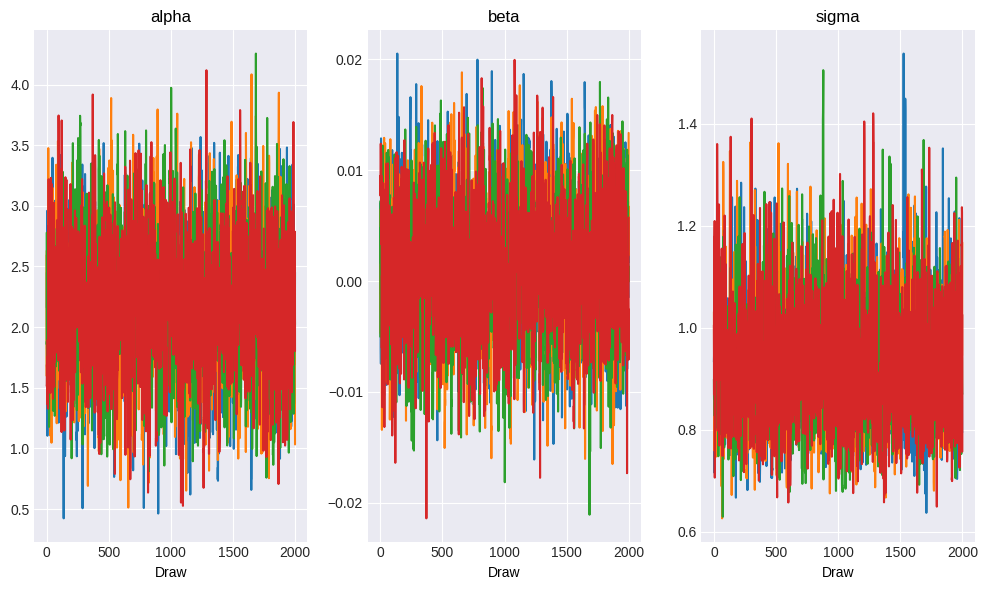

In [22]:
# Statistical summary of the estimated parameters
display(az.summary(trace, round_to=3))

# Trace plots adapted to your ArviZ version
az.plot_trace(trace, figure_kwargs={"figsize": (10, 6)})
plt.tight_layout()
plt.show()

# 7. Visualizing Posterior Structural Uncertainty

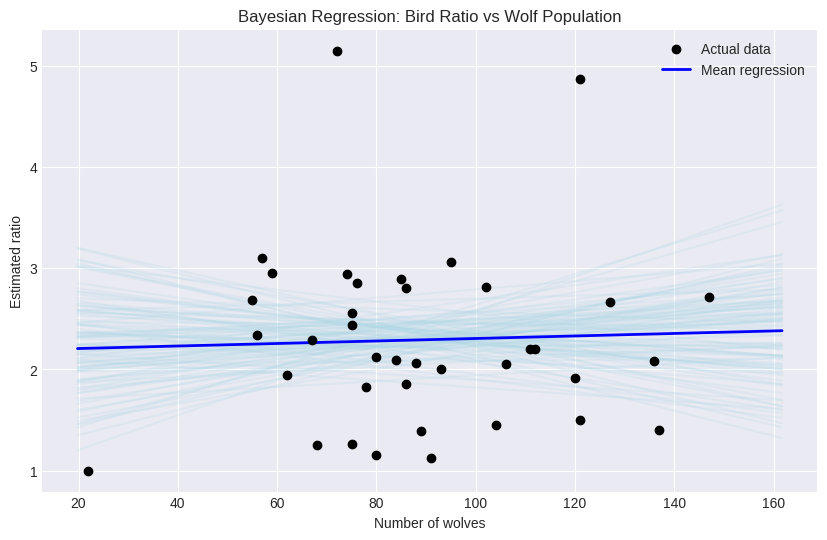

In [23]:
plt.figure(figsize=(10, 6))

# Plotting observed data
plt.scatter(wolves_x, birds_ratio_y, color='black', label='Actual data', zorder=5)

# Defining the X axis for line plotting
x_seq = np.linspace(wolves_x.min() * 0.9, wolves_x.max() * 1.1, 100)
alpha_samples = trace.posterior['alpha'].values.flatten()
beta_samples = trace.posterior['beta'].values.flatten()

# Plotting uncertainty (100 lines drawn from the posterior distribution)
idx = np.random.choice(len(alpha_samples), 100, replace=False)
for i in idx:
    plt.plot(x_seq, alpha_samples[i] + beta_samples[i] * x_seq, color='lightblue', alpha=0.2)

# Plotting the mean regression line
mu_mean = alpha_samples.mean() + beta_samples.mean() * x_seq
plt.plot(x_seq, mu_mean, color='blue', lw=2, label='Mean regression')

plt.title("Bayesian Regression: Bird Ratio vs Wolf Population")
plt.xlabel("Number of wolves")
plt.ylabel("Estimated ratio")
plt.legend()
plt.show()